<a href="https://colab.research.google.com/github/mohamadfaisalbashir/midterm-machine-learning/blob/main/clustering/customer_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 **End-to-End Customer Clustering Pipeline**
---
👤 **Author Profile**
* **Name:** Mohamad Faisal Bashir
* **Class:** TK-47-04
* **NIM:** 101032300036
---
### 📖 **Task Overview:**
In this assignment, you will build a customer clustering pipeline. You will use a customer dataset, clean and preprocess the data, handle missing values and outliers, and prepare useful features. Then you will apply unsupervised learning methods (such as k-means, hierarchical clustering, or DBSCAN) to group customers based on their spending and payment behavior. Your workflow should include data preprocessing, model training, choosing the number of clusters, evaluating the clusters, and explaining what each cluster represents.

---
### 📌 **Workflow Pipeline:**

1. **Environment Setup & Library Imports** (scikit-learn, pandas, seaborn, scipy)
2. **Data Loading & Initial Exploration (EDA)**
3. **Data Cleaning & Missing Value Handling** (Median & KNN Imputation)
4. **Outlier Detection & Treatment** (IQR Capping / Winsorization)
5. **Feature Engineering** (Deriving behavioral signals like Balance-to-Limit, Cash Advance Ratio)
6. **Preprocessing** (RobustScaler & PCA for Dimensionality Reduction)
7. **K-Means Clustering** (Optimal *k* selection via Elbow, Silhouette, & Davies-Bouldin)
8. **Hierarchical Clustering** (Dendrogram visualization & Ward's linkage)
9. **DBSCAN Clustering** (Density-based spatial clustering & noise/anomaly detection)
10. **Algorithm Comparison & Evaluation** (Silhouette, Davies-Bouldin, Calinski-Harabasz)
11. **Cluster Profiling & Business Interpretation** (Defining personas and strategic actions)

### 📊 **Dataset:**
- **File**: `clusteringmidterm.csv` (Credit Card / Spending Dataset)
- **Target**: Unsupervised (No predefined target variable; grouping is based on feature similarities).

> 💡 **Key Findings / Characteristics**: The algorithms successfully identified 3 main customer segments:
> 1. **"The Active Transactors" (90.9%)**: Healthy financial profile, target for loyalty programs.
> 2. **"The Cash Advance Users" (6.4%)**: High limits but use the card purely for cash liquidity.
> 3. **"The High-Risk / Defaulters" (2.7%)**: Non-paying segment with growing balances, requiring immediate credit freezing.

---
## 📦 Section 0 — Install & Import Libraries

import all required libraries up front for transparency and reproducibility.

In [1]:
#  Standard library
import warnings
warnings.filterwarnings('ignore')

#  Data manipulation
import numpy as np
import pandas as pd

#  Visualisation
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from matplotlib.gridspec import GridSpec

#  Preprocessing
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.decomposition import PCA

#  Clustering algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

#  Cluster evaluation
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score
)

#  Hierarchical / dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

#  Reproducibility
SEED = 42
np.random.seed(SEED)

#  Plotting style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

print('✅ All libraries imported successfully.')

✅ All libraries imported successfully.


---
## 📂 Section 1 — Data Loading & Initial Exploration

We begin by mounting Google Drive (Colab) and loading the CSV.  
Our first goal is to understand the shape, types, and quality of the data.

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
print('✅ Google Drive mounted.')

Mounted at /content/drive
✅ Google Drive mounted.


In [3]:
#  Load dataset
DATA_PATH = '/content/drive/MyDrive/ML/clusteringmidterm.csv'

df_raw = pd.read_csv(DATA_PATH)

print(f'Dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head()

Dataset loaded: 8,950 rows × 18 columns


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
#  Dataset structure
# dtypes, non-null counts, and memory footprint
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [5]:
#  Descriptive statistics
# This gives us range, mean, std, quartiles — critical for spotting outliers
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CUST_ID,8950,8950,C19190,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BALANCE,8950.0,NaN,NaN,NaN,1564.474828,2081.531879,0.0,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,NaN,NaN,NaN,0.877271,0.236904,0.0,0.888889,1.0,1.0,1.0
PURCHASES,8950.0,NaN,NaN,NaN,1003.204834,2136.634782,0.0,39.635,361.28,1110.13,49039.57
ONEOFF_PURCHASES,8950.0,NaN,NaN,NaN,592.437371,1659.887917,0.0,0.0,38.0,577.405,40761.25
INSTALLMENTS_PURCHASES,8950.0,NaN,NaN,NaN,411.067645,904.338115,0.0,0.0,89.0,468.6375,22500.0
CASH_ADVANCE,8950.0,NaN,NaN,NaN,978.871112,2097.163877,0.0,0.0,0.0,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,NaN,NaN,NaN,0.490351,0.401371,0.0,0.083333,0.5,0.916667,1.0
ONEOFF_PURCHASES_FREQUENCY,8950.0,NaN,NaN,NaN,0.202458,0.298336,0.0,0.0,0.083333,0.3,1.0
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,NaN,NaN,NaN,0.364437,0.397448,0.0,0.0,0.166667,0.75,1.0


Columns with missing values:
                  Missing Count  Missing %
MINIMUM_PAYMENTS            313       3.50
CREDIT_LIMIT                  1       0.01


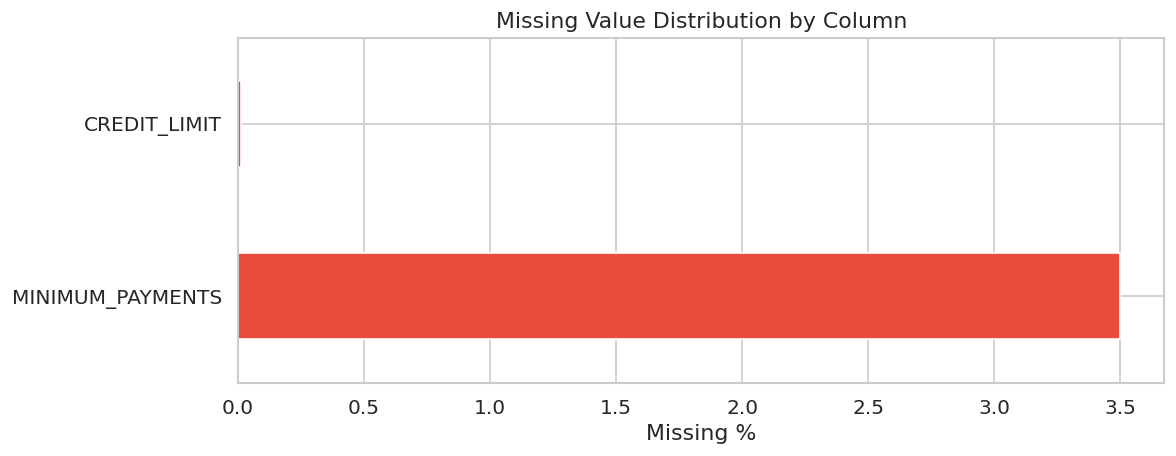

In [6]:
#  Missing value audit
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print('Columns with missing values:')
print(missing_report.to_string() if not missing_report.empty else '  ✅ No missing values detected.')

# Visualise missing data pattern
if not missing_report.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_report['Missing %'].plot(kind='barh', ax=ax, color='#e74c3c', edgecolor='white')
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Value Distribution by Column')
    plt.tight_layout()
    plt.show()

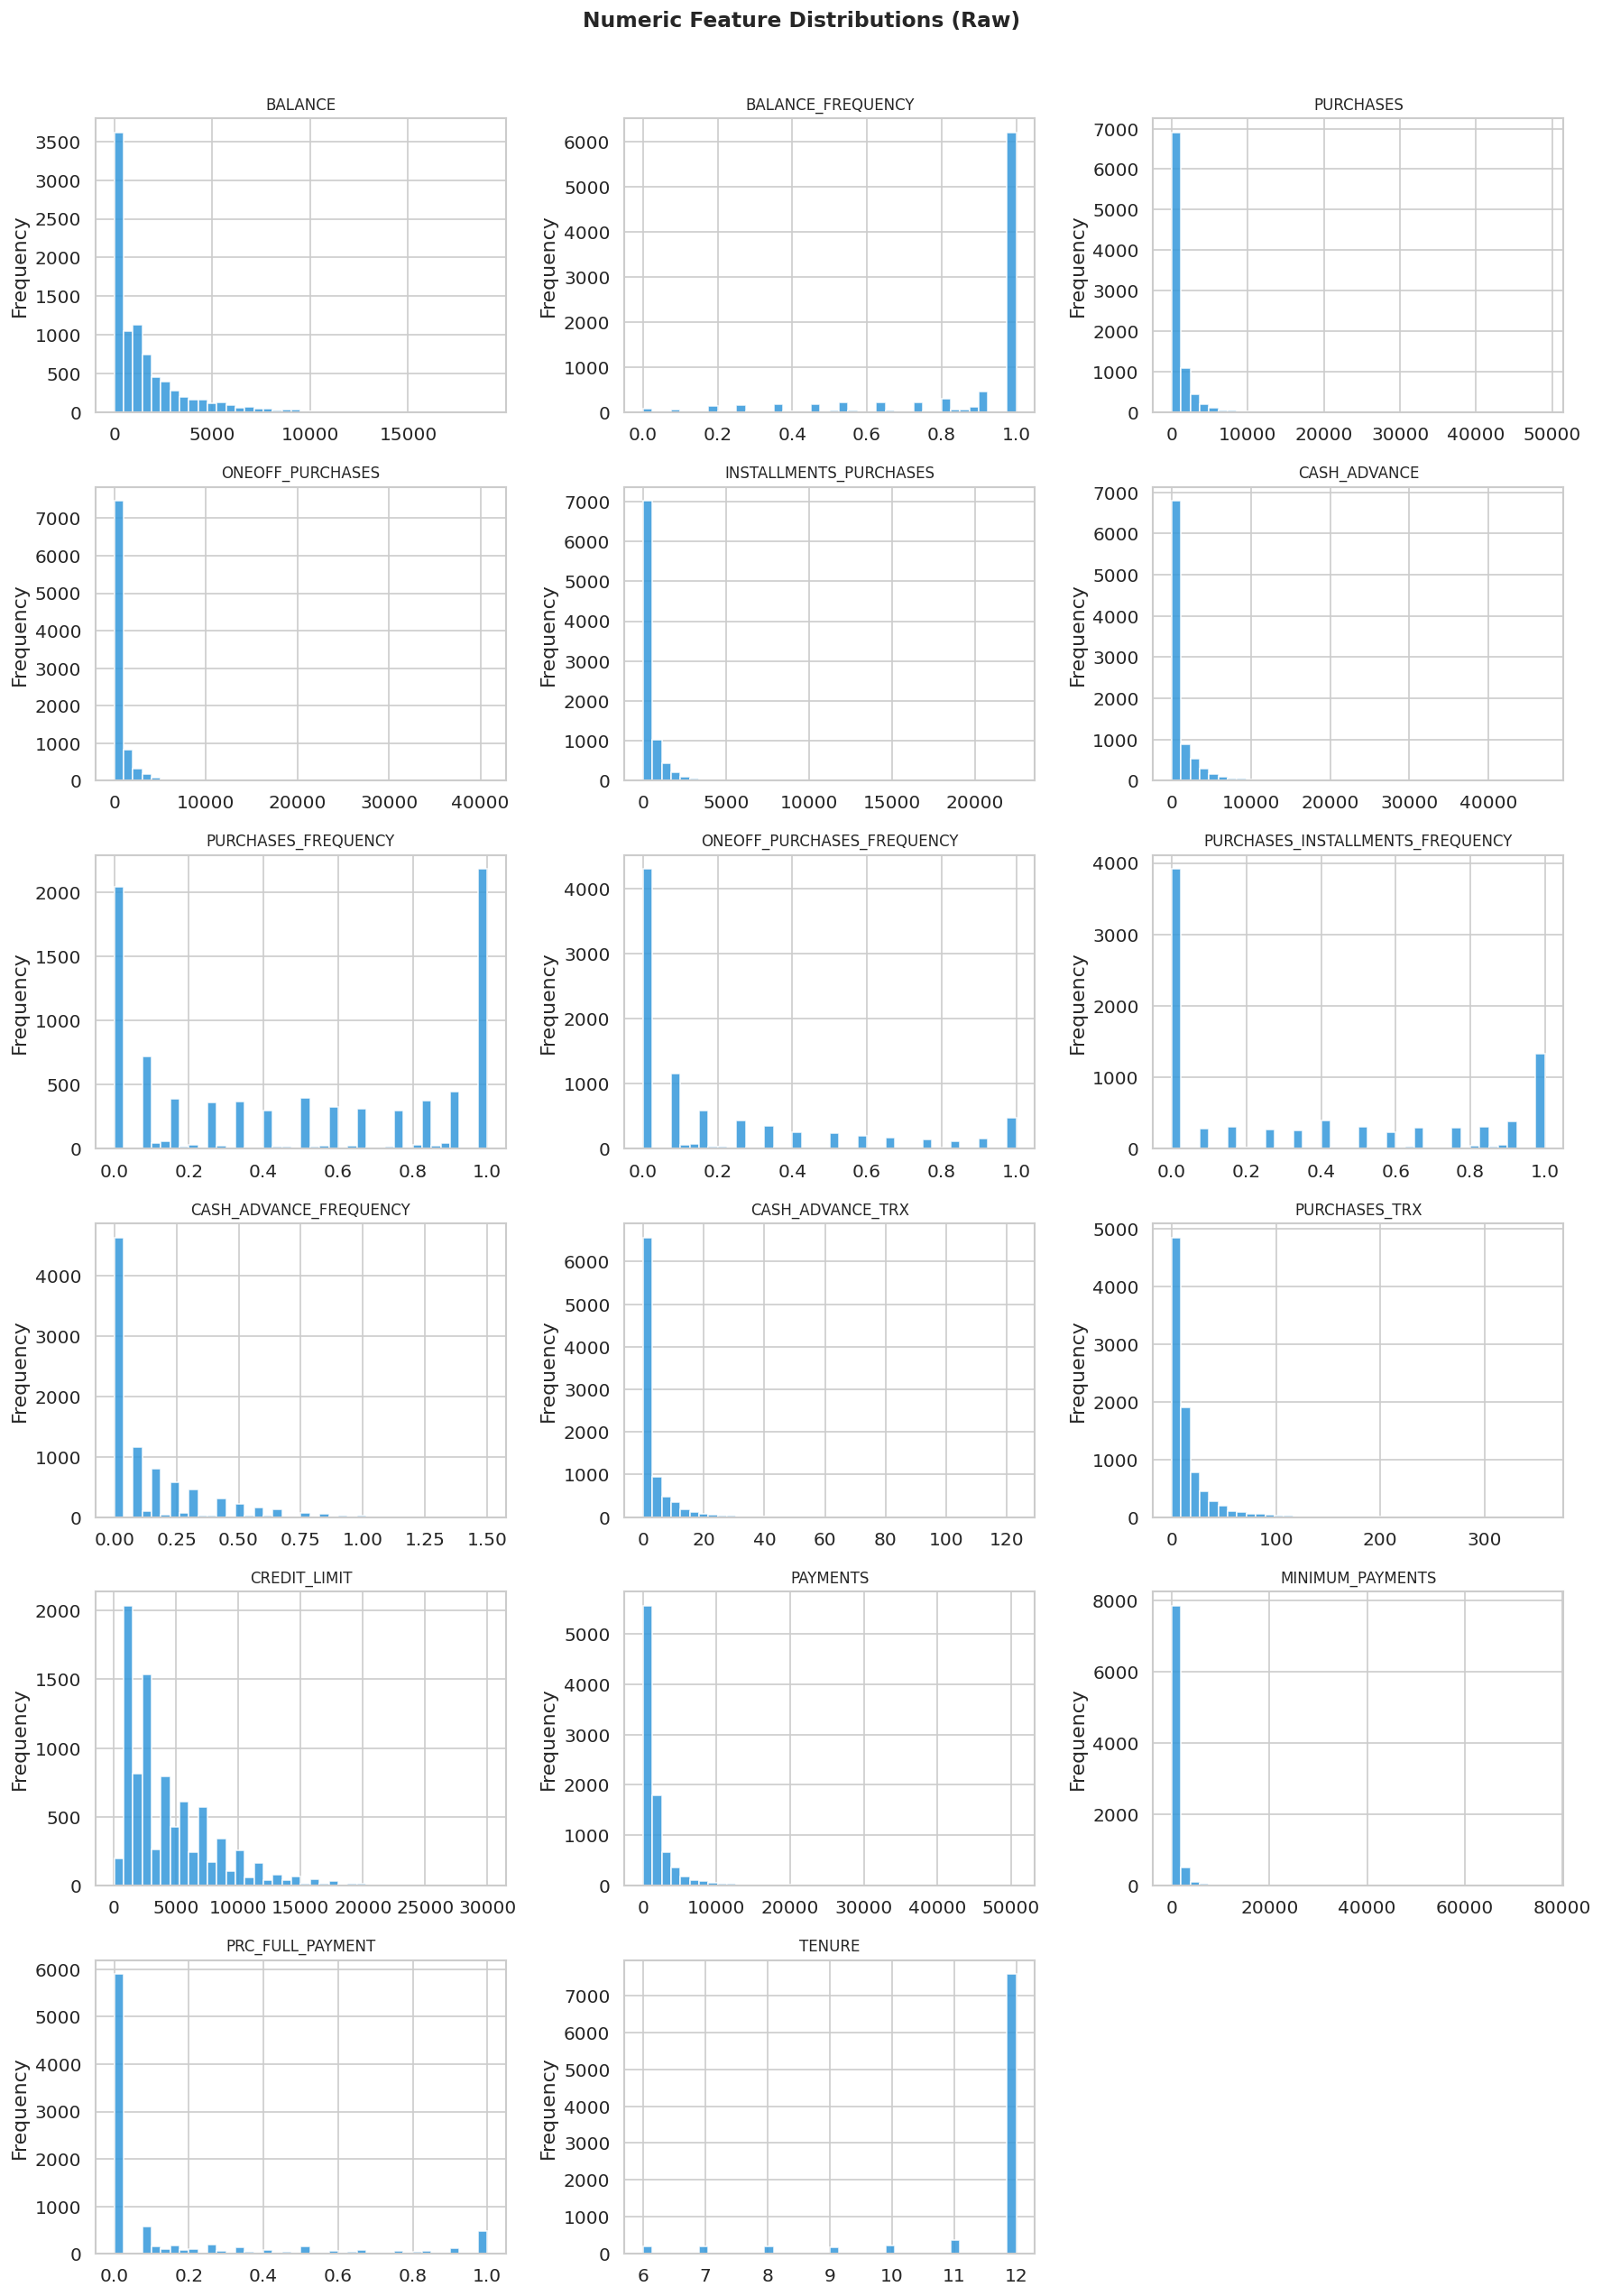

In [7]:
#  Feature distributions (numeric columns)
numeric_cols = df_raw.select_dtypes(include=np.number).columns.tolist()

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df_raw[col].dropna(), bins=40, color='#3498db', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Numeric Feature Distributions (Raw)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 🧹 Section 2 — Data Cleaning & Missing Value Handling

**Strategy:**
- Drop ID/irrelevant columns (e.g. `CUST_ID`) — they carry no clustering signal
- For columns with **< 5% missing**: use **median imputation** (robust to skew)
- For columns with **5–30% missing**: use **KNN imputation** (leverages neighbouring records)
- For columns with **> 30% missing**: drop the column entirely
- Drop duplicate rows

In [8]:
#  Work on a copy — never mutate the raw frame
df = df_raw.copy()

# Drop customer ID columns (non-informative for clustering)
id_cols = [c for c in df.columns if 'ID' in c.upper() or 'CUST' in c.upper()]
if id_cols:
    df.drop(columns=id_cols, inplace=True)
    print(f'Dropped ID columns: {id_cols}')

# Drop duplicate rows
n_dupes = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f'Dropped {n_dupes} duplicate rows.')
print(f'Shape after deduplication: {df.shape}')

Dropped ID columns: ['CUST_ID']
Dropped 0 duplicate rows.
Shape after deduplication: (8950, 17)


In [9]:
#  Tiered missing-value imputation
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
missing_pct_now = df[numeric_cols].isnull().mean() * 100

# Tier thresholds
drop_threshold = 30
knn_threshold =  5

cols_to_drop = missing_pct_now[missing_pct_now > drop_threshold].index.tolist()
cols_knn = missing_pct_now[(missing_pct_now > knn_threshold) & (missing_pct_now <= drop_threshold)].index.tolist()
cols_median = missing_pct_now[(missing_pct_now > 0) & (missing_pct_now <= knn_threshold)].index.tolist()

print(f'Drop (>{drop_threshold}%):  {cols_to_drop}')
print(f'KNN impute ({knn_threshold}-{drop_threshold}%): {cols_knn}')
print(f'Median impute (<{knn_threshold}%): {cols_median}')

# Drop high-missing columns
df.drop(columns=cols_to_drop, inplace=True)

# Median imputation (fast, robust to outliers)
if cols_median:
    median_imp = SimpleImputer(strategy='median')
    df[cols_median] = median_imp.fit_transform(df[cols_median])

# KNN imputation (captures feature correlations)
if cols_knn:
    knn_imp = KNNImputer(n_neighbors=5, weights='distance')
    df[cols_knn] = knn_imp.fit_transform(df[cols_knn])

print(f'\n✅ Missing values remaining: {df.isnull().sum().sum()}')

Drop (>30%):  []
KNN impute (5-30%): []
Median impute (<5%): ['CREDIT_LIMIT', 'MINIMUM_PAYMENTS']

✅ Missing values remaining: 0


---
## 🔍 Section 3 — Outlier Detection & Treatment

Outliers distort cluster centroids — especially in K-Means.  

**Approach:**  
- Visualise with box plots  
- Use **IQR capping (Winsorization)** at the 1st–99th percentile  
  → This *preserves* all rows while capping extreme values, which is safer than deletion for clustering

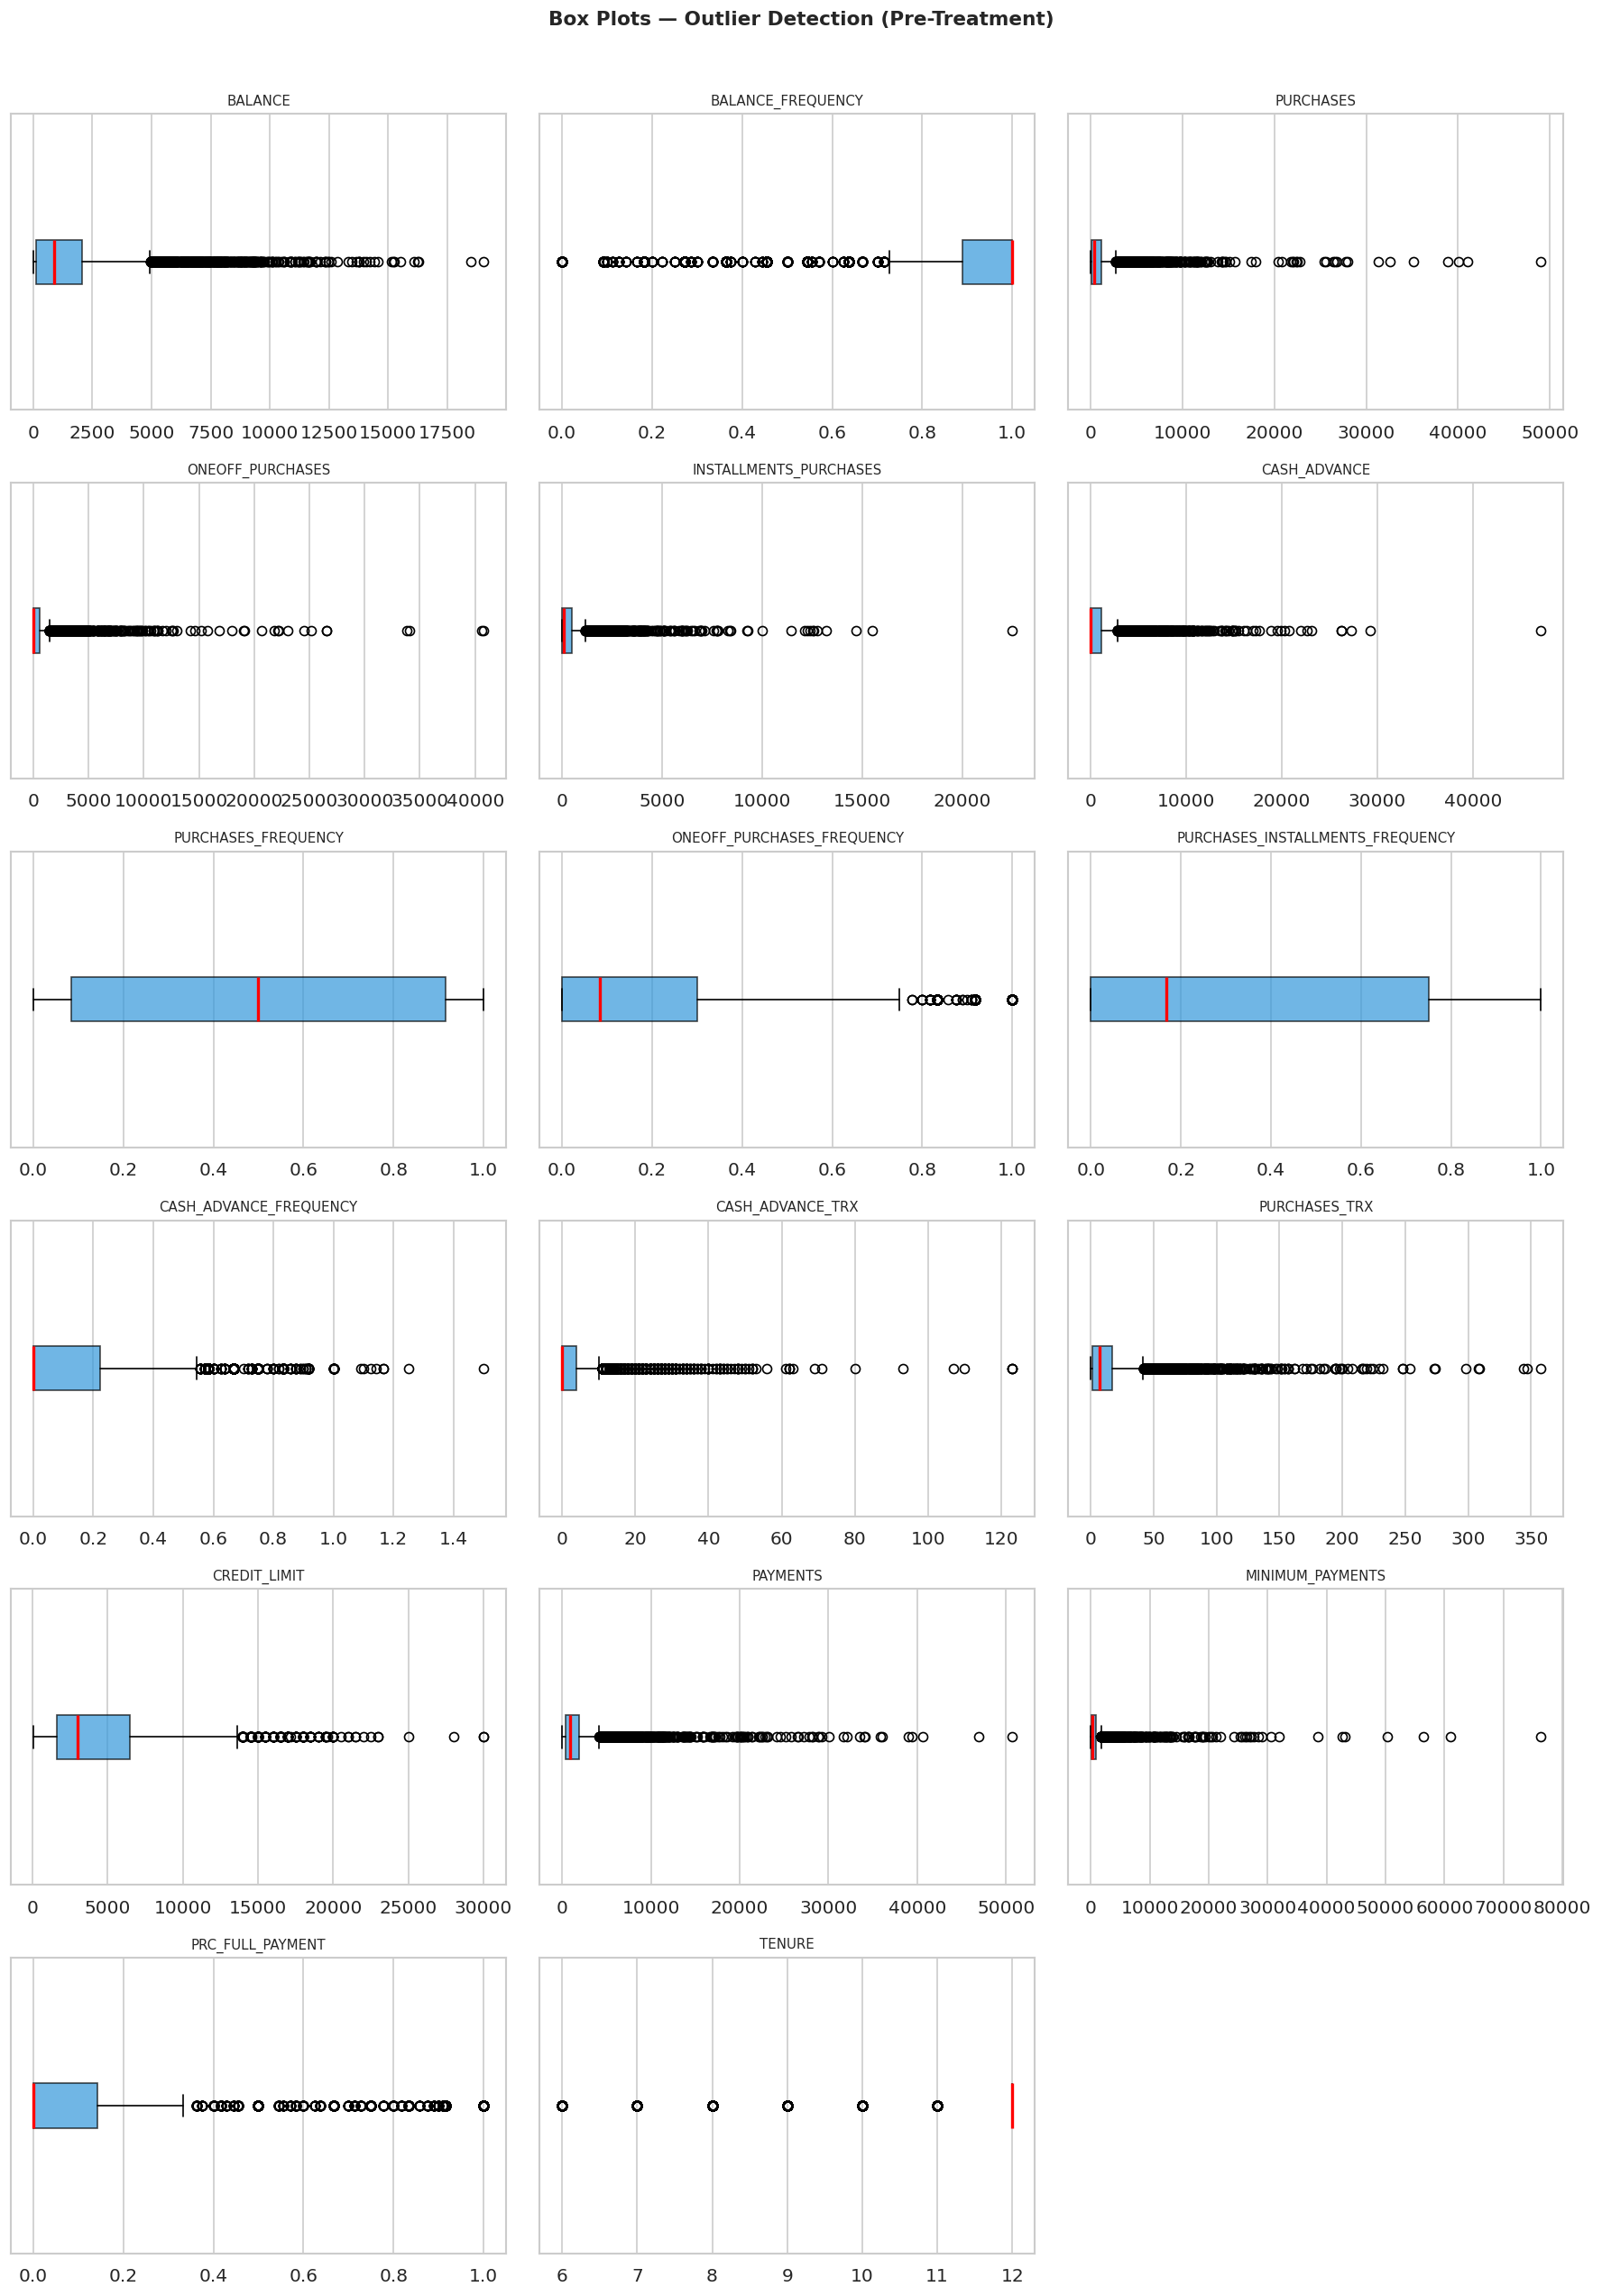

In [10]:
#  Box plots before treatment
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), vert=False, patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_yticks([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Box Plots — Outlier Detection (Pre-Treatment)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [11]:
#  IQR Winsorization (cap at 1st & 99th percentile)

def winsorize_iqr(series, lower_pct=0.01, upper_pct=0.99):
    lower = series.quantile(lower_pct)
    upper = series.quantile(upper_pct)
    return series.clip(lower=lower, upper=upper)

df_clean = df.copy()
for col in numeric_cols:
    df_clean[col] = winsorize_iqr(df_clean[col])

print(f'✅ Winsorization applied to {len(numeric_cols)} numeric columns.')
print(f'Dataset shape (unchanged): {df_clean.shape}')

✅ Winsorization applied to 17 numeric columns.
Dataset shape (unchanged): (8950, 17)


---
## ⚙️ Section 4 — Feature Engineering

Raw columns are good — but **derived features** often reveal richer behavioural signals.  

For a typical credit card / spending dataset we engineer:

| Feature | Formula | Insight |
|---|---|---|
| `BALANCE_TO_LIMIT_RATIO` | BALANCE / CREDIT_LIMIT | Credit utilisation rate |
| `PAYMENT_TO_BALANCE_RATIO` | PAYMENTS / BALANCE | Repayment behaviour |
| `AVG_PURCHASE_PER_TXN` | PURCHASES / PURCHASES_TRX | Spend per transaction |
| `CASH_ADVANCE_RATIO` | CASH_ADVANCE / (PURCHASES + 1) | Preference for cash vs card |
| `TENURE_ACTIVITY_SCORE` | PURCHASES / TENURE | Activity relative to account age |

> **Note:** Adjust column names below to match your actual dataset columns.

In [12]:
#  Feature engineering
df_feat = df_clean.copy()

cols = df_feat.columns.str.upper().tolist()
df_feat.columns = df_feat.columns.str.upper()  # normalise column names

def safe_ratio(num, denom, df, fill=0.0):
    if num in df.columns and denom in df.columns:
        return df[num] / (df[denom] + 1e-9)  # +epsilon avoids division by zero
    return pd.Series(fill, index=df.index)

# Credit utilisation
df_feat['BALANCE_TO_LIMIT_RATIO'] = safe_ratio('BALANCE', 'CREDIT_LIMIT', df_feat)

# Repayment behaviour
df_feat['PAYMENT_TO_BALANCE_RATIO'] = safe_ratio('PAYMENTS', 'BALANCE', df_feat)

# Average purchase per transaction
df_feat['AVG_PURCHASE_PER_TXN'] = safe_ratio('PURCHASES', 'PURCHASES_TRX', df_feat)

# Cash advance preference
df_feat['CASH_ADVANCE_RATIO'] = safe_ratio('CASH_ADVANCE', 'PURCHASES', df_feat)

# Activity score (purchases per unit of tenure)
df_feat['TENURE_ACTIVITY_SCORE'] = safe_ratio('PURCHASES', 'TENURE', df_feat)

# Minimum payment compliance rate
df_feat['MIN_PAY_COMPLIANCE'] = safe_ratio('MINIMUM_PAYMENTS', 'PAYMENTS', df_feat)

#  Drop any all-zero engineered features (columns that didn't map)
new_feats = ['BALANCE_TO_LIMIT_RATIO', 'PAYMENT_TO_BALANCE_RATIO',
             'AVG_PURCHASE_PER_TXN', 'CASH_ADVANCE_RATIO',
             'TENURE_ACTIVITY_SCORE', 'MIN_PAY_COMPLIANCE']

active_feats = [f for f in new_feats if df_feat[f].std() > 0]
print(f'Engineered features added: {active_feats}')
print(f'Total features: {df_feat.shape[1]}')
df_feat.head(3)

Engineered features added: ['BALANCE_TO_LIMIT_RATIO', 'PAYMENT_TO_BALANCE_RATIO', 'AVG_PURCHASE_PER_TXN', 'CASH_ADVANCE_RATIO', 'TENURE_ACTIVITY_SCORE', 'MIN_PAY_COMPLIANCE']
Total features: 23


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,BALANCE_TO_LIMIT_RATIO,PAYMENT_TO_BALANCE_RATIO,AVG_PURCHASE_PER_TXN,CASH_ADVANCE_RATIO,TENURE_ACTIVITY_SCORE,MIN_PAY_COMPLIANCE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.0,0.083333,0.00,...,201.802084,139.509787,0.000000,12,0.040901,4.933946,47.700000,0.000000e+00,7.950000,0.691320
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.0,0.000000,0.25,...,4103.032597,1072.340217,0.222222,12,0.457495,1.281210,0.000000,6.442945e+12,0.000000,0.261353
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.0,0.000000,0.00,...,622.066742,627.284787,0.000000,12,0.332687,0.249310,64.430833,0.000000e+00,64.430833,1.008388


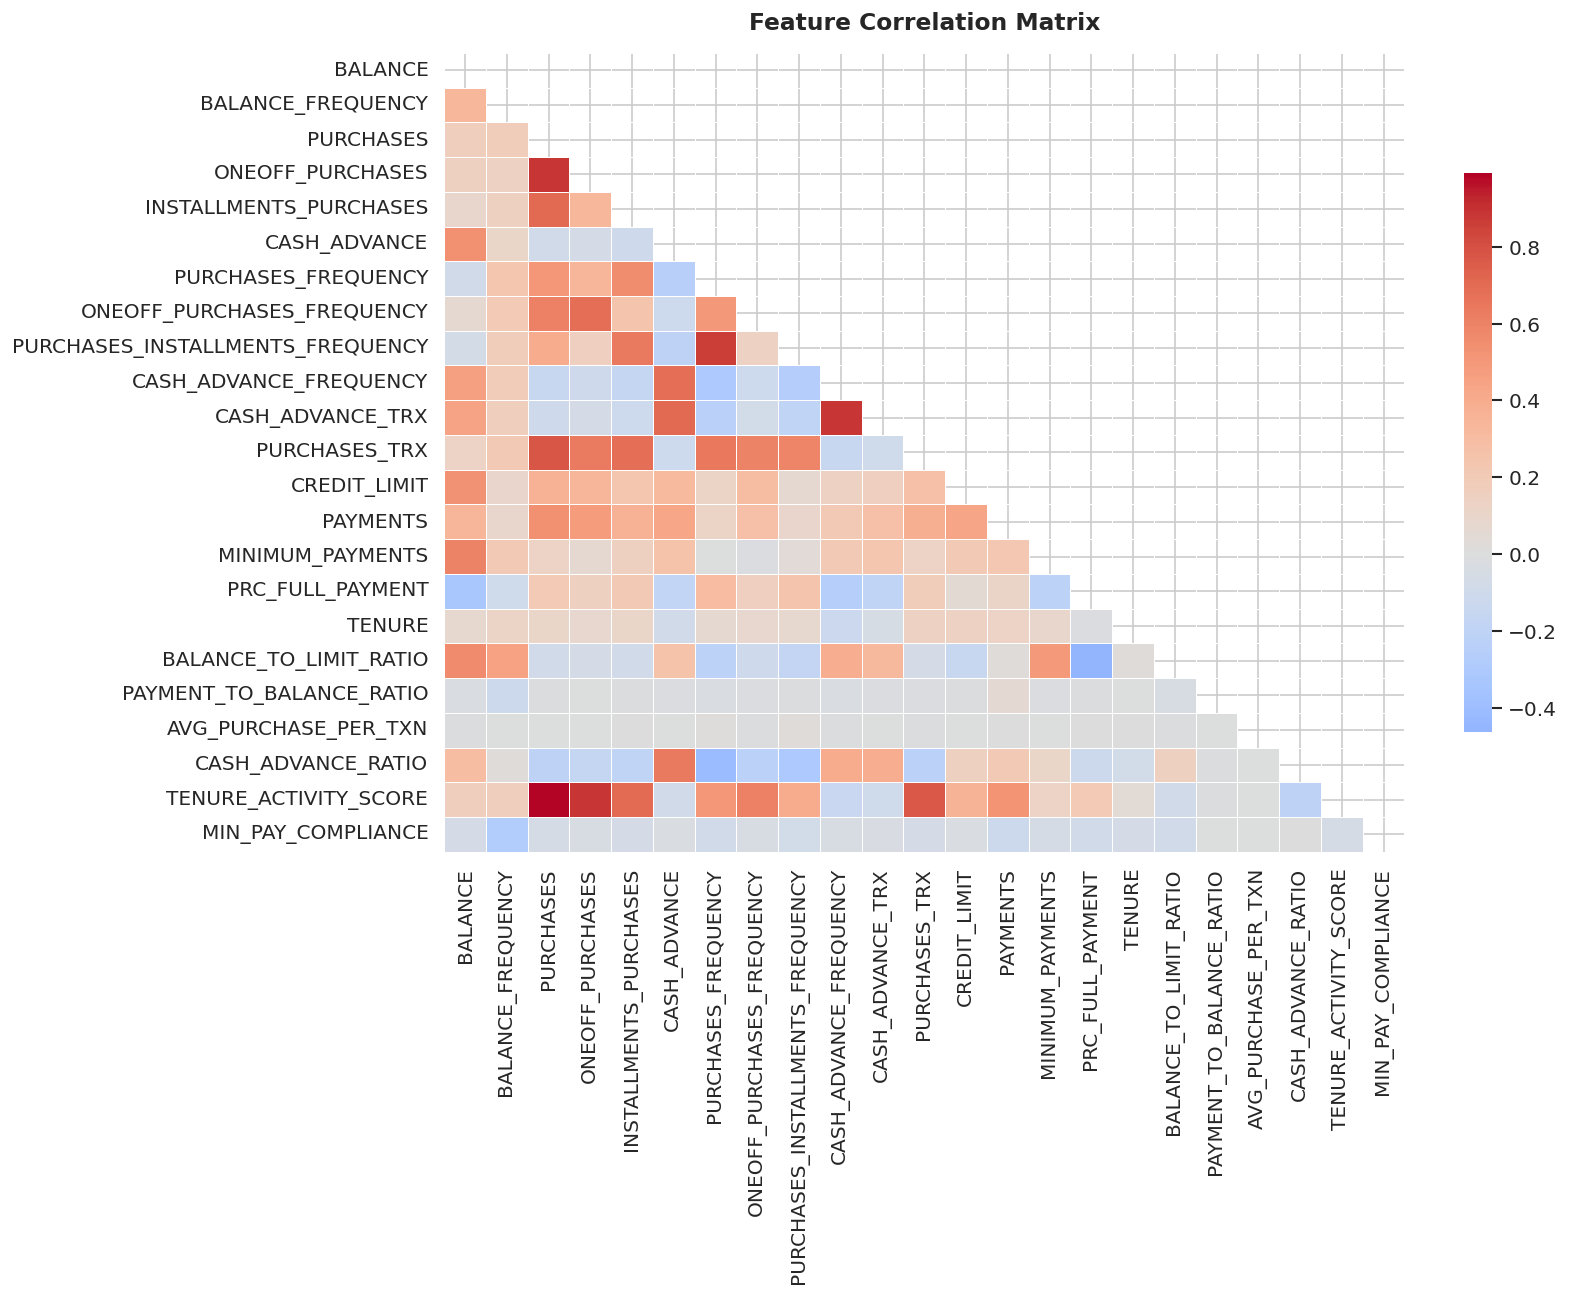

In [13]:
#  Correlation heatmap
corr = df_feat.select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0,
            linewidths=0.4, ax=ax, square=False,
            cbar_kws={'shrink': 0.7})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

---
## 📐 Section 5 — Preprocessing: Scaling & Dimensionality Reduction

**Why scale?**  
Distance-based algorithms (K-Means, DBSCAN) are sensitive to feature magnitude.  
A column ranging 0–1,000,000 dominates over one ranging 0–1.  

We use **`RobustScaler`** (scales by IQR), which is more resistant to remaining outliers than `StandardScaler`.

We then apply **PCA** for:
1. Visualising clusters in 2D
2. Optional: reducing to the top components that explain ≥ 90% variance to reduce noise

In [14]:
#  Select only numeric columns for clustering
cluster_cols = df_feat.select_dtypes(include=np.number).columns.tolist()
X_raw = df_feat[cluster_cols].values

#  RobustScaler: (x - median) / IQR — robust to outliers
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f'Scaled matrix shape: {X_scaled.shape}')
print(f'Mean after scaling (should ≈ 0): {X_scaled.mean():.4f}')
print(f'Std  after scaling (should ≈ 1): {X_scaled.std():.4f}')

Scaled matrix shape: (8950, 23)
Mean after scaling (should ≈ 0): 1325798994.3295
Std  after scaling (should ≈ 1): 18035541334.6534


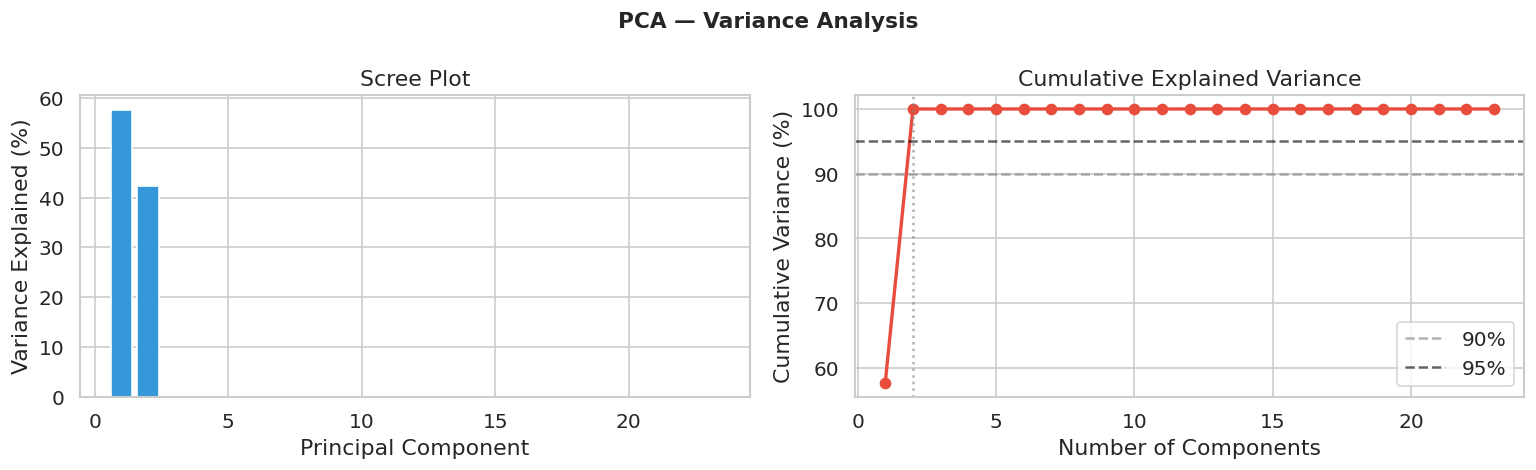

Components to explain 90% variance: 2
Components to explain 95% variance: 2


In [15]:
#  PCA — full fit to study variance explained
pca_full = PCA(random_state=SEED)
pca_full.fit(X_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_90 = np.argmax(cum_var >= 0.90) + 1
n_components_95 = np.argmax(cum_var >= 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scree plot
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_ * 100,
            color='#3498db', edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot')

# Cumulative variance
axes[1].plot(range(1, len(cum_var) + 1), cum_var * 100, 'o-', color='#e74c3c', lw=2)
axes[1].axhline(90, linestyle='--', color='gray', alpha=0.6, label='90%')
axes[1].axhline(95, linestyle='--', color='black', alpha=0.6, label='95%')
axes[1].axvline(n_components_90, linestyle=':', color='gray', alpha=0.6)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.suptitle('PCA — Variance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Components to explain 90% variance: {n_components_90}')
print(f'Components to explain 95% variance: {n_components_95}')

In [16]:
#  PCA 2D for visualisation only
pca_2d = PCA(n_components=2, random_state=SEED)
X_pca2d = pca_2d.fit_transform(X_scaled)

#  PCA nD for clustering (90% variance threshold)
pca_nd = PCA(n_components=n_components_90, random_state=SEED)
X_pca_nd = pca_nd.fit_transform(X_scaled)

print(f'2D PCA shape (visualisation): {X_pca2d.shape}')
print(f'nD PCA shape (clustering):    {X_pca_nd.shape}')

2D PCA shape (visualisation): (8950, 2)
nD PCA shape (clustering):    (8950, 2)


---
## 📊 Section 6 — K-Means Clustering

**K-Means** partitions data into *k* spherical clusters by minimising within-cluster sum of squares.  

**Choosing k — we use three criteria in parallel:**
1. **Elbow Method** — plot inertia (WCSS) vs k; elbow = diminishing returns
2. **Silhouette Score** — measures cluster cohesion & separation (higher = better, max 1.0)
3. **Davies-Bouldin Index** — ratio of within-cluster scatter to between-cluster distance (lower = better)

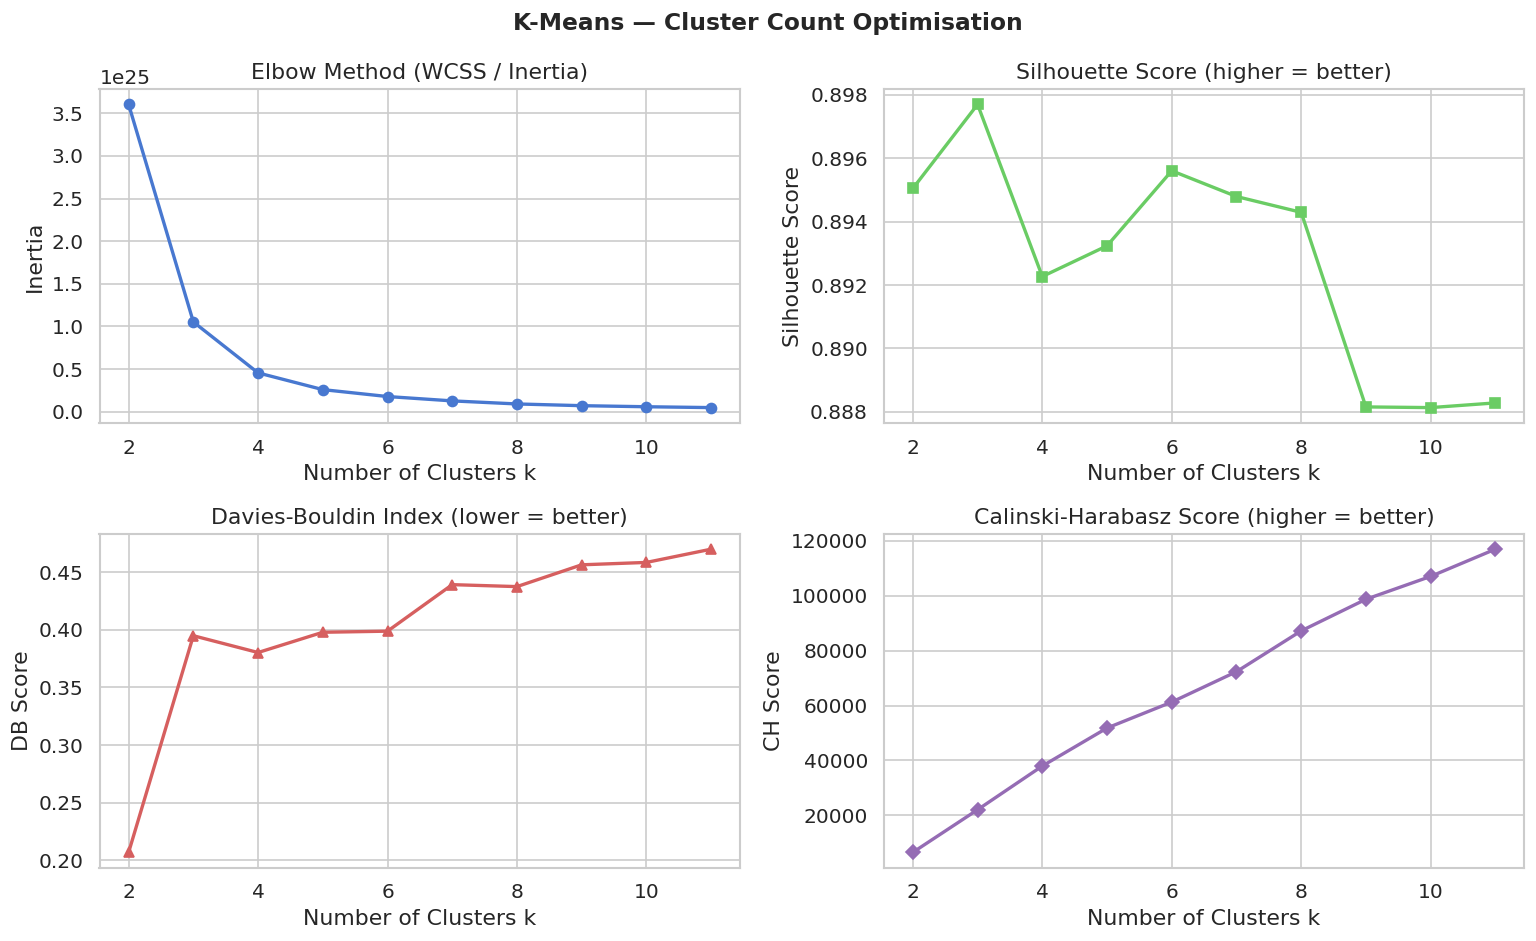

 k      Inertia  Silhouette  Davies-Bouldin  Calinski-Harabasz
 2 3.604366e+25      0.8950          0.2070            6559.47
 3 1.052627e+25      0.8977          0.3949           22073.58
 4 4.547205e+24      0.8923          0.3803           37982.49
 5 2.584692e+24      0.8932          0.3979           51810.68
 6 1.772297e+24      0.8956          0.3988           61258.89
 7 1.261482e+24      0.8948          0.4392           72316.03
 8 9.021596e+23      0.8943          0.4375           87172.42
 9 6.998204e+23      0.8882          0.4564           98667.57
10 5.746249e+23      0.8881          0.4585          106992.77
11 4.740559e+23      0.8883          0.4700          116901.07


In [17]:
#  Elbow + Silhouette + Davies-Bouldin sweep
K_RANGE = range(2, 12)  # test k = 2 to 11

inertias     = []
silhouettes  = []
db_scores    = []
ch_scores    = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, max_iter=500, random_state=SEED)
    labels = km.fit_predict(X_pca_nd)

    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca_nd, labels))
    db_scores.append(davies_bouldin_score(X_pca_nd, labels))
    ch_scores.append(calinski_harabasz_score(X_pca_nd, labels))

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0,0].plot(K_RANGE, inertias, 'bo-', lw=2, ms=6)
axes[0,0].set_title('Elbow Method (WCSS / Inertia)')
axes[0,0].set_xlabel('Number of Clusters k')
axes[0,0].set_ylabel('Inertia')

axes[0,1].plot(K_RANGE, silhouettes, 'gs-', lw=2, ms=6)
axes[0,1].set_title('Silhouette Score (higher = better)')
axes[0,1].set_xlabel('Number of Clusters k')
axes[0,1].set_ylabel('Silhouette Score')

axes[1,0].plot(K_RANGE, db_scores, 'r^-', lw=2, ms=6)
axes[1,0].set_title('Davies-Bouldin Index (lower = better)')
axes[1,0].set_xlabel('Number of Clusters k')
axes[1,0].set_ylabel('DB Score')

axes[1,1].plot(K_RANGE, ch_scores, 'mD-', lw=2, ms=6)
axes[1,1].set_title('Calinski-Harabasz Score (higher = better)')
axes[1,1].set_xlabel('Number of Clusters k')
axes[1,1].set_ylabel('CH Score')

fig.suptitle('K-Means — Cluster Count Optimisation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table
score_df = pd.DataFrame({
    'k': list(K_RANGE),
    'Inertia': inertias,
    'Silhouette': [round(s, 4) for s in silhouettes],
    'Davies-Bouldin': [round(d, 4) for d in db_scores],
    'Calinski-Harabasz': [round(c, 2) for c in ch_scores]
})
print(score_df.to_string(index=False))

In [18]:
#  Select optimal k

OPTIMAL_K = silhouettes.index(max(silhouettes)) + 2  # default: k with best silhouette
print(f'🎯 Optimal k selected: {OPTIMAL_K}')
print('   (Override manually if elbow/DBI suggest otherwise)')

🎯 Optimal k selected: 3
   (Override manually if elbow/DBI suggest otherwise)


In [19]:
#  Final K-Means model
kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=30,
                max_iter=500, random_state=SEED)
df_feat['KMeans_Label'] = kmeans.fit_predict(X_pca_nd)

km_sil = silhouette_score(X_pca_nd, df_feat['KMeans_Label'])
km_db  = davies_bouldin_score(X_pca_nd, df_feat['KMeans_Label'])
print(f'K-Means  |  k={OPTIMAL_K}  |  Silhouette: {km_sil:.4f}  |  Davies-Bouldin: {km_db:.4f}')

K-Means  |  k=3  |  Silhouette: 0.8977  |  Davies-Bouldin: 0.3949


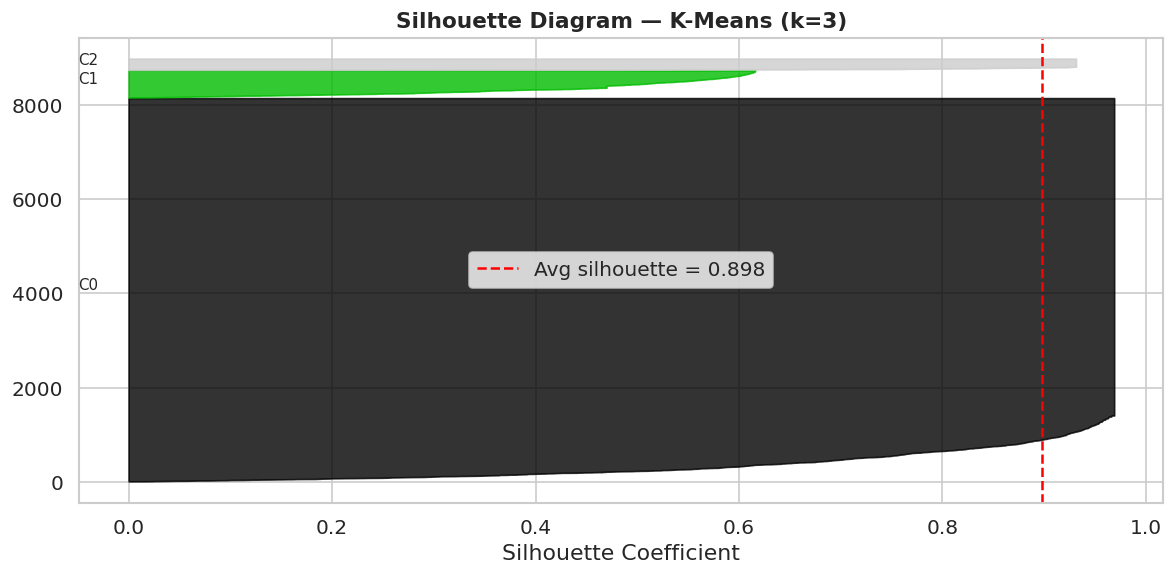

In [20]:
#  Silhouette diagram — per-sample quality
sample_sil = silhouette_samples(X_pca_nd, df_feat['KMeans_Label'])

fig, ax = plt.subplots(figsize=(10, 5))
y_lower = 10
colors = cm.nipy_spectral(np.linspace(0, 1, OPTIMAL_K))

for i in range(OPTIMAL_K):
    cluster_sil = np.sort(sample_sil[df_feat['KMeans_Label'] == i])
    size = cluster_sil.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                      facecolor=colors[i], edgecolor=colors[i], alpha=0.8)
    ax.text(-0.05, y_lower + 0.5 * size, f'C{i}', fontsize=9)
    y_lower = y_upper + 10

ax.axvline(km_sil, color='red', linestyle='--', lw=1.5, label=f'Avg silhouette = {km_sil:.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_title(f'Silhouette Diagram — K-Means (k={OPTIMAL_K})', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

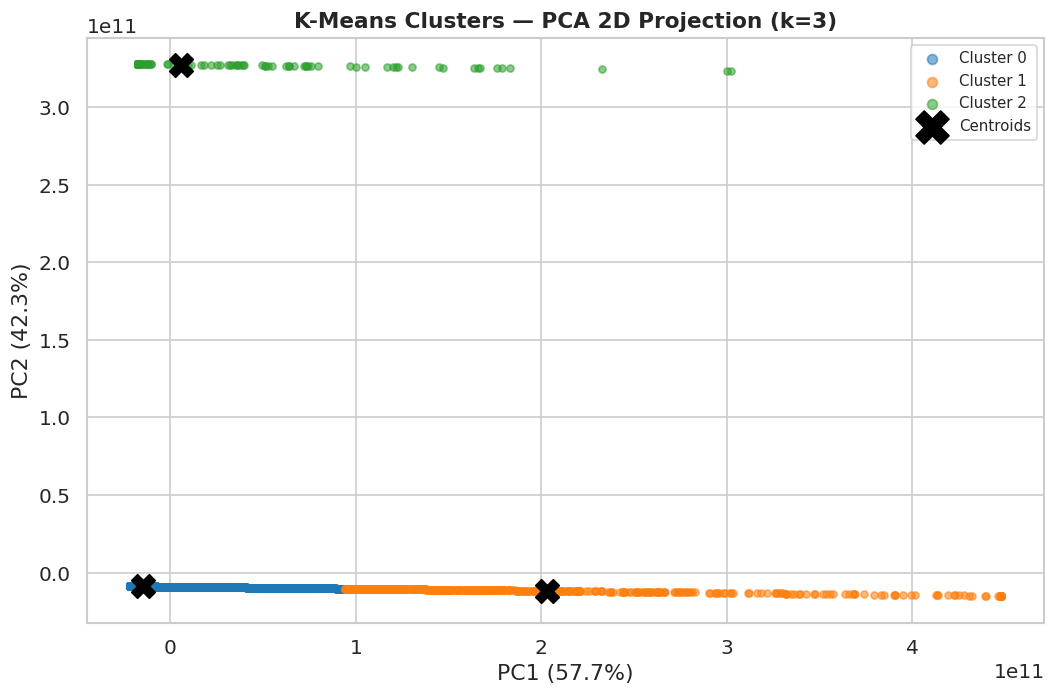

In [21]:
#  2D PCA scatter — K-Means clusters
fig, ax = plt.subplots(figsize=(9, 6))
palette = sns.color_palette('tab10', OPTIMAL_K)

for k in range(OPTIMAL_K):
    mask = df_feat['KMeans_Label'] == k
    ax.scatter(X_pca2d[mask, 0], X_pca2d[mask, 1],
               s=18, alpha=0.55, color=palette[k], label=f'Cluster {k}')

# Plot centroids projected to 2D
centroids_2d = pca_2d.transform(pca_nd.inverse_transform(kmeans.cluster_centers_))
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1], s=200,
           marker='X', c='black', zorder=5, label='Centroids')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'K-Means Clusters — PCA 2D Projection (k={OPTIMAL_K})', fontsize=13, fontweight='bold')
ax.legend(markerscale=1.4, fontsize=9)
plt.tight_layout()
plt.show()

---
## 🌲 Section 7 — Hierarchical Clustering

Hierarchical clustering does **not** require pre-specifying *k* — the dendrogram reveals natural breaks.  

We use **Ward's linkage** (minimises within-cluster variance), which generally produces compact, equally-sized clusters.  

**When to use over K-Means:**  
- When cluster shape is unknown  
- When you want a visual hierarchy of merges  
- Smaller datasets (O(n²) complexity)

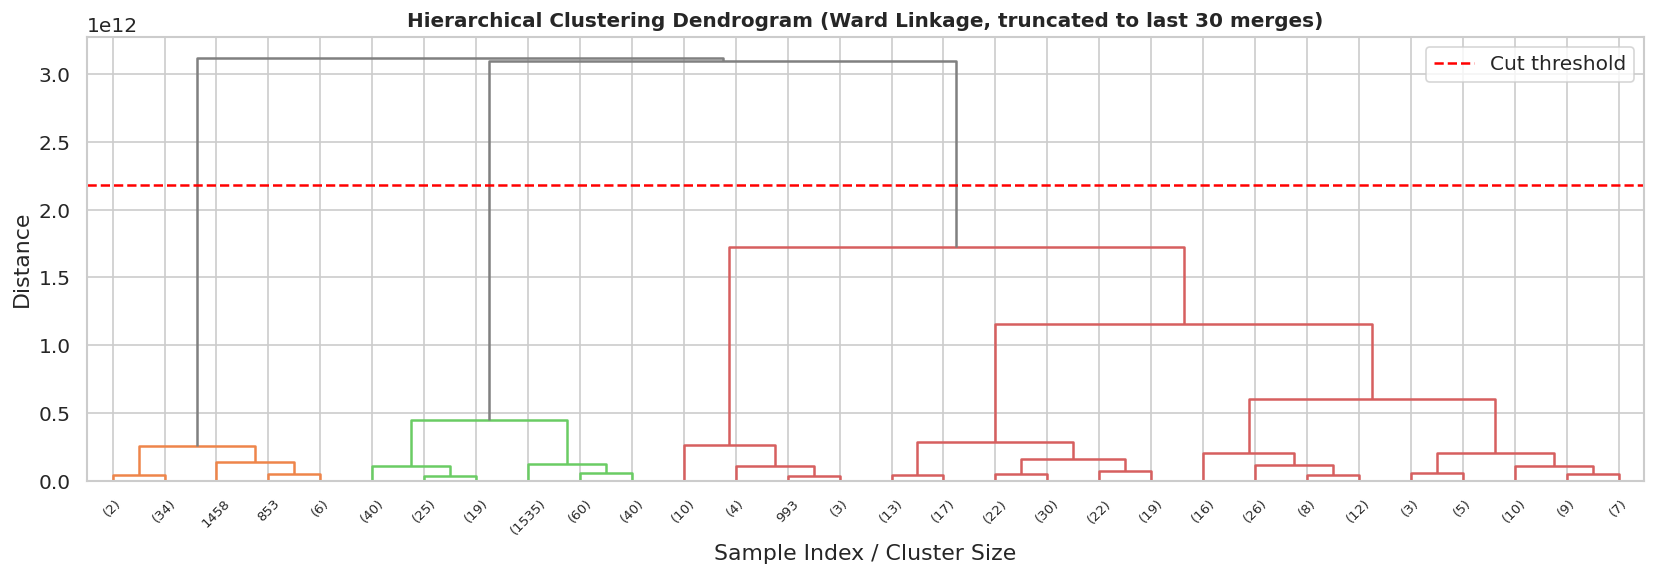

📌 The gap between the last two merges (tallest vertical lines) suggests the natural cluster count.


In [22]:
#  Dendrogram (subsample for performance if N > 2000)
MAX_DENDRO_SAMPLES = 2000
idx = np.random.choice(len(X_pca_nd), min(MAX_DENDRO_SAMPLES, len(X_pca_nd)), replace=False)
X_dendro = X_pca_nd[idx]

Z = linkage(X_dendro, method='ward', metric='euclidean')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=45, leaf_font_size=8,
           color_threshold=0.7 * max(Z[:, 2]),
           above_threshold_color='gray')
ax.set_title('Hierarchical Clustering Dendrogram (Ward Linkage, truncated to last 30 merges)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Sample Index / Cluster Size')
ax.set_ylabel('Distance')
ax.axhline(y=0.7 * max(Z[:, 2]), color='red', linestyle='--', lw=1.5,
           label='Cut threshold')
ax.legend()
plt.tight_layout()
plt.show()

print('📌 The gap between the last two merges (tallest vertical lines) suggests the natural cluster count.')

In [23]:
#  Fit Agglomerative Clustering with the same k
agg = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
df_feat['Hierarchical_Label'] = agg.fit_predict(X_pca_nd)

hc_sil = silhouette_score(X_pca_nd, df_feat['Hierarchical_Label'])
hc_db  = davies_bouldin_score(X_pca_nd, df_feat['Hierarchical_Label'])
print(f'Hierarchical  |  k={OPTIMAL_K}  |  Silhouette: {hc_sil:.4f}  |  Davies-Bouldin: {hc_db:.4f}')

Hierarchical  |  k=3  |  Silhouette: 0.8982  |  Davies-Bouldin: 0.3374


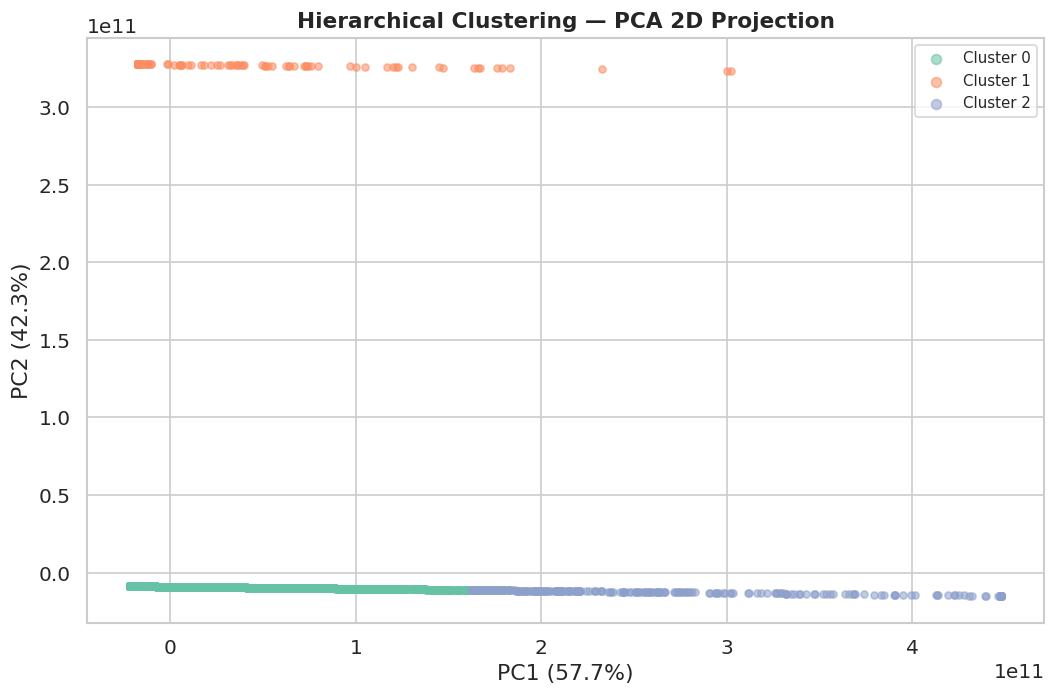

In [24]:
#  2D scatter — Hierarchical clusters
fig, ax = plt.subplots(figsize=(9, 6))
palette = sns.color_palette('Set2', OPTIMAL_K)

for k in range(OPTIMAL_K):
    mask = df_feat['Hierarchical_Label'] == k
    ax.scatter(X_pca2d[mask, 0], X_pca2d[mask, 1],
               s=18, alpha=0.55, color=palette[k], label=f'Cluster {k}')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Hierarchical Clustering — PCA 2D Projection', fontsize=13, fontweight='bold')
ax.legend(markerscale=1.4, fontsize=9)
plt.tight_layout()
plt.show()

---
## 🔵 Section 8 — DBSCAN Clustering

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) finds **arbitrarily shaped** clusters and marks low-density points as **noise (−1)**.  

**Key hyperparameters:**
- `eps` — neighbourhood radius. Use k-distance plot (k=minPts) to find the "knee"  
- `min_samples` — minimum neighbours to be a core point. Rule of thumb: 2× dimensions

**When to prefer DBSCAN:**  
- Non-convex, irregular cluster shapes  
- When noise/outlier detection matters  
- When k is truly unknown

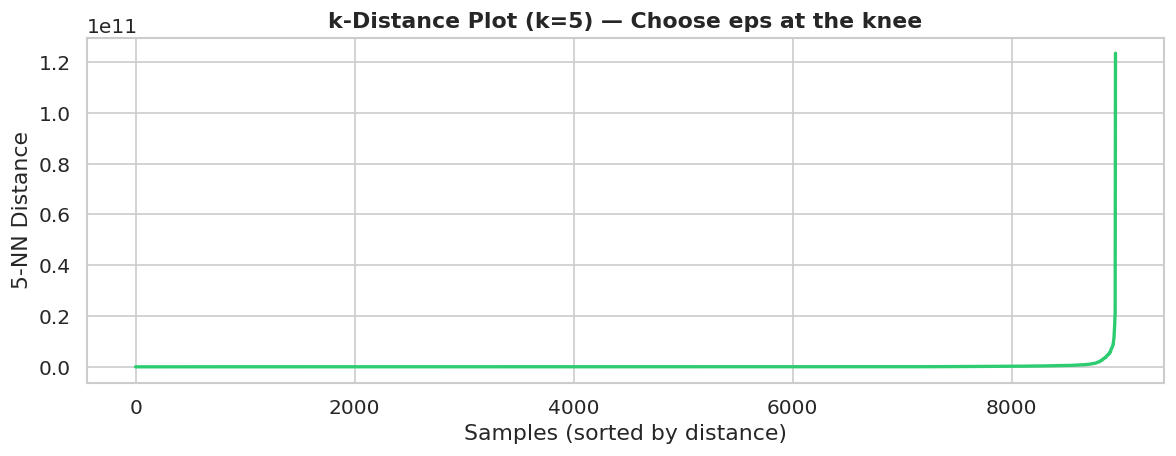

Auto-detected eps (knee): 21385434749.3690
Adjust EPS_VALUE below if the knee is not sharp.


In [25]:
#  k-distance plot to choose eps
from sklearn.neighbors import NearestNeighbors

MIN_SAMPLES = max(5, 2 * X_pca_nd.shape[1])  # heuristic: 2 × dimensions

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nbrs.fit(X_pca_nd)
distances, _ = nbrs.kneighbors(X_pca_nd)
kth_dist = np.sort(distances[:, -1])  # distance to kth nearest neighbour

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(kth_dist, color='#2ecc71', lw=2)
ax.set_xlabel('Samples (sorted by distance)')
ax.set_ylabel(f'{MIN_SAMPLES}-NN Distance')
ax.set_title(f'k-Distance Plot (k={MIN_SAMPLES}) — Choose eps at the knee', fontweight='bold')
plt.tight_layout()
plt.show()

#  Auto-detect knee using max second derivative
second_deriv = np.gradient(np.gradient(kth_dist))
knee_idx = np.argmax(second_deriv)
EPS_AUTO = kth_dist[knee_idx]
print(f'Auto-detected eps (knee): {EPS_AUTO:.4f}')
print(f'Adjust EPS_VALUE below if the knee is not sharp.')

In [26]:
#  DBSCAN fit
EPS_VALUE = EPS_AUTO  # override manually if auto-detection is off

dbscan = DBSCAN(eps=EPS_VALUE, min_samples=MIN_SAMPLES, metric='euclidean', n_jobs=-1)
df_feat['DBSCAN_Label'] = dbscan.fit_predict(X_pca_nd)

n_clusters_db = len(set(df_feat['DBSCAN_Label'])) - (1 if -1 in df_feat['DBSCAN_Label'].values else 0)
n_noise       = (df_feat['DBSCAN_Label'] == -1).sum()
pct_noise     = n_noise / len(df_feat) * 100

print(f'DBSCAN found {n_clusters_db} clusters')
print(f'Noise points: {n_noise} ({pct_noise:.1f}%)')

# Silhouette requires ≥ 2 clusters and no all-noise
if n_clusters_db >= 2:
    non_noise = df_feat['DBSCAN_Label'] != -1
    db_sil = silhouette_score(X_pca_nd[non_noise], df_feat.loc[non_noise, 'DBSCAN_Label'])
    print(f'Silhouette (excl. noise): {db_sil:.4f}')
else:
    print('⚠️  Adjust eps — too few clusters. Increase eps or decrease min_samples.')

DBSCAN found 2 clusters
Noise points: 3 (0.0%)
Silhouette (excl. noise): 0.8953


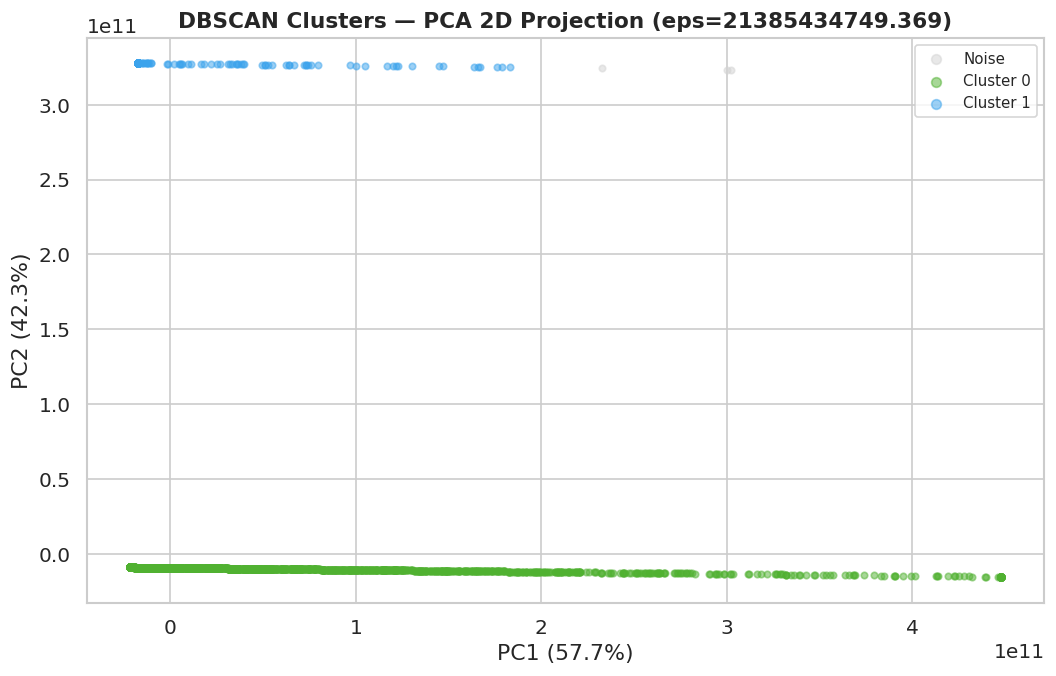

In [27]:
#  2D scatter — DBSCAN clusters
unique_labels = sorted(df_feat['DBSCAN_Label'].unique())
palette = sns.color_palette('husl', len(unique_labels))

fig, ax = plt.subplots(figsize=(9, 6))
for i, lbl in enumerate(unique_labels):
    mask = df_feat['DBSCAN_Label'] == lbl
    color = 'lightgray' if lbl == -1 else palette[i]
    label = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    ax.scatter(X_pca2d[mask, 0], X_pca2d[mask, 1],
               s=15, alpha=0.5, color=color, label=label)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'DBSCAN Clusters — PCA 2D Projection (eps={EPS_VALUE:.3f})', fontsize=13, fontweight='bold')
ax.legend(markerscale=1.5, fontsize=9, loc='best')
plt.tight_layout()
plt.show()

---
## 🏆 Section 9 — Algorithm Comparison

We compare all three algorithms side-by-side using standard metrics.

   Algorithm  n_clusters  Silhouette  Davies-Bouldin
     K-Means           3      0.8977          0.3949
Hierarchical           3      0.8982          0.3374
      DBSCAN           2      0.8953             NaN


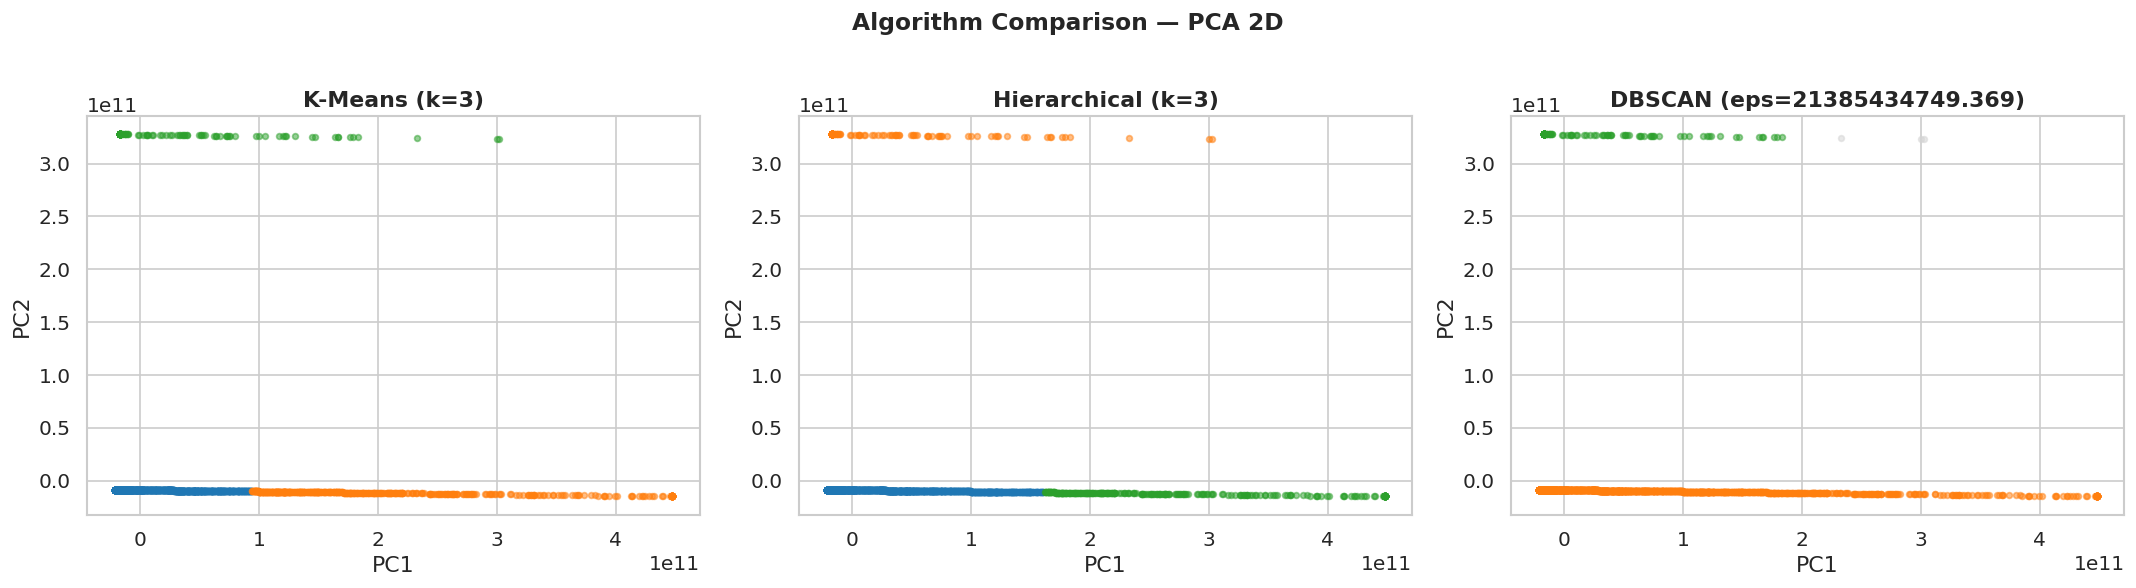

In [28]:
#  Side-by-side metric comparison
results = [
    {'Algorithm': 'K-Means',       'n_clusters': OPTIMAL_K,    'Silhouette': km_sil, 'Davies-Bouldin': km_db},
    {'Algorithm': 'Hierarchical',  'n_clusters': OPTIMAL_K,    'Silhouette': hc_sil, 'Davies-Bouldin': hc_db},
]

if n_clusters_db >= 2:
    results.append({'Algorithm': 'DBSCAN', 'n_clusters': n_clusters_db, 'Silhouette': db_sil, 'Davies-Bouldin': None})

results_df = pd.DataFrame(results)
results_df['Silhouette'] = results_df['Silhouette'].round(4)
results_df['Davies-Bouldin'] = results_df['Davies-Bouldin'].round(4)
print(results_df.to_string(index=False))

#  Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette2d = sns.color_palette('tab10', OPTIMAL_K)

for ax, (label_col, title) in zip(axes, [
    ('KMeans_Label',       f'K-Means (k={OPTIMAL_K})'),
    ('Hierarchical_Label', f'Hierarchical (k={OPTIMAL_K})'),
    ('DBSCAN_Label',       f'DBSCAN (eps={EPS_VALUE:.3f})'),
]):
    unique = sorted(df_feat[label_col].unique())
    pal = sns.color_palette('tab10', len(unique))
    for i, lbl in enumerate(unique):
        m = df_feat[label_col] == lbl
        c = 'lightgray' if lbl == -1 else pal[i]
        ax.scatter(X_pca2d[m, 0], X_pca2d[m, 1], s=12, alpha=0.5, color=c)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

fig.suptitle('Algorithm Comparison — PCA 2D', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔎 Section 10 — Cluster Profiling & Business Interpretation

Now we **interpret what each cluster means** in business terms.  
We use K-Means labels (typically most stable) — swap to hierarchical if it scored better.

For each cluster we compute:
- **Mean** of key features
- **Relative z-score** compared to the population mean
- A **persona narrative** describing the customer type

In [29]:
#  Cluster means (original, un-scaled for interpretability)
LABEL_COL = 'KMeans_Label'  # switch to 'Hierarchical_Label' if preferred

profile_cols = [c for c in df_feat.select_dtypes(include=np.number).columns
                if c not in ['KMeans_Label', 'Hierarchical_Label', 'DBSCAN_Label']]

cluster_profile = df_feat.groupby(LABEL_COL)[profile_cols].mean().round(3)
cluster_profile.index.name = 'Cluster'
cluster_profile.T

Cluster,0,1,2
BALANCE,1.414774e+03,3.661182e+03,7.229550e+02
BALANCE_FREQUENCY,8.880000e-01,9.010000e-01,4.800000e-01
PURCHASES,1.018071e+03,0.000000e+00,4.136610e+02
ONEOFF_PURCHASES,5.820340e+02,0.000000e+00,2.830700e+02
INSTALLMENTS_PURCHASES,4.192700e+02,1.160000e-01,1.302940e+02
CASH_ADVANCE,6.831540e+02,4.588897e+03,7.192040e+02
PURCHASES_FREQUENCY,5.310000e-01,0.000000e+00,2.840000e-01
ONEOFF_PURCHASES_FREQUENCY,2.190000e-01,0.000000e+00,1.270000e-01
PURCHASES_INSTALLMENTS_FREQUENCY,3.960000e-01,0.000000e+00,1.810000e-01
CASH_ADVANCE_FREQUENCY,1.170000e-01,3.880000e-01,8.300000e-02


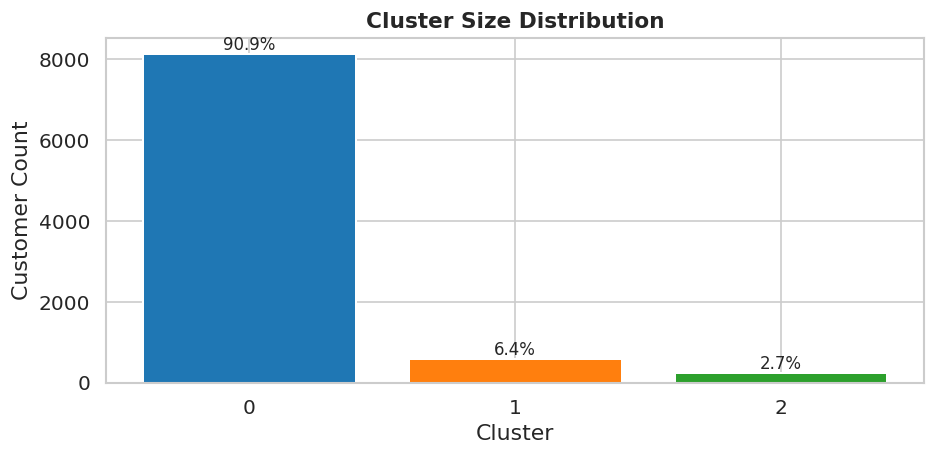

In [30]:
#  Cluster size distribution
sizes = df_feat[LABEL_COL].value_counts().sort_index()
pcts  = (sizes / len(df_feat) * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(sizes.index.astype(str), sizes.values,
              color=sns.color_palette('tab10', OPTIMAL_K),
              edgecolor='white', linewidth=1.2)
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{pct}%', ha='center', va='bottom', fontsize=10)
ax.set_xlabel('Cluster')
ax.set_ylabel('Customer Count')
ax.set_title('Cluster Size Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

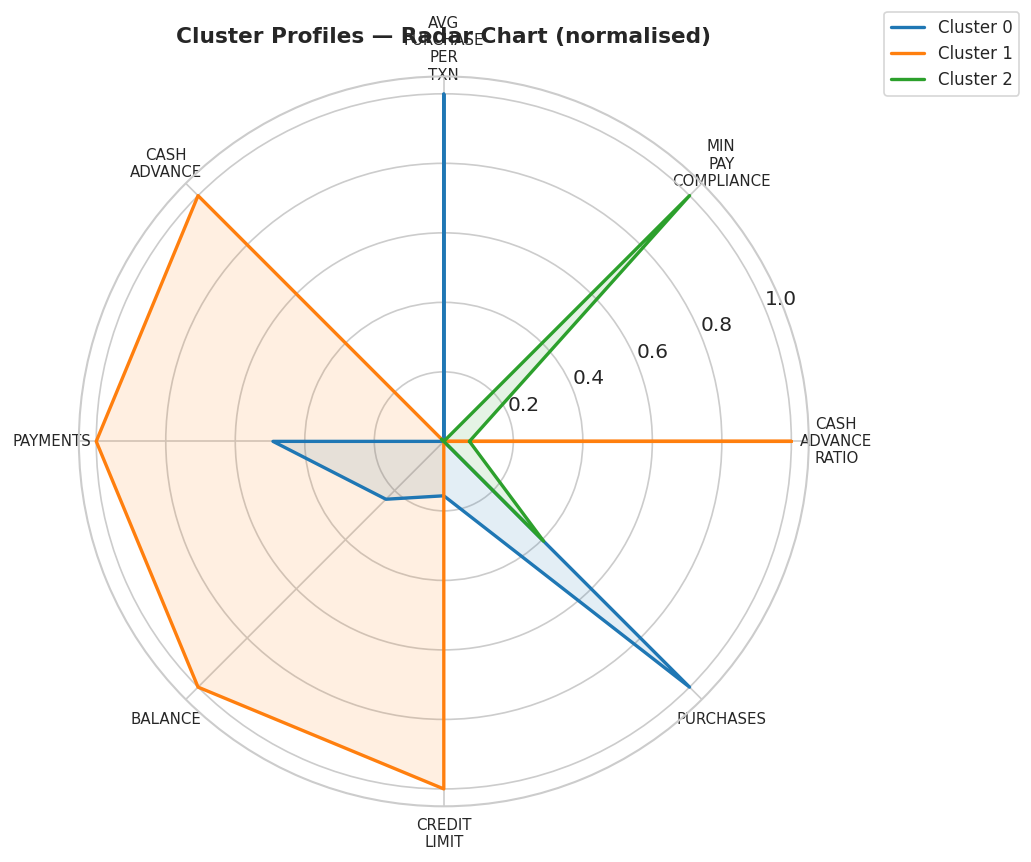

In [31]:
#  Radar / spider chart — relative cluster profiles
# Normalise cluster means to [0,1] per feature for comparable radar arms

# Pick top 8 most descriptive features (highest inter-cluster variance)
inter_var = cluster_profile.var(axis=0).sort_values(ascending=False)
radar_feats = inter_var.head(8).index.tolist()

radar_data = cluster_profile[radar_feats].copy()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min() + 1e-9)

N = len(radar_feats)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
palette = sns.color_palette('tab10', OPTIMAL_K)

for k in range(OPTIMAL_K):
    vals = radar_norm.iloc[k].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, lw=2, color=palette[k], label=f'Cluster {k}')
    ax.fill(angles, vals, alpha=0.12, color=palette[k])

ax.set_xticks(angles[:-1])
ax.set_xticklabels([f.replace('_', '\n') for f in radar_feats], fontsize=9)
ax.set_title('Cluster Profiles — Radar Chart (normalised)', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.show()

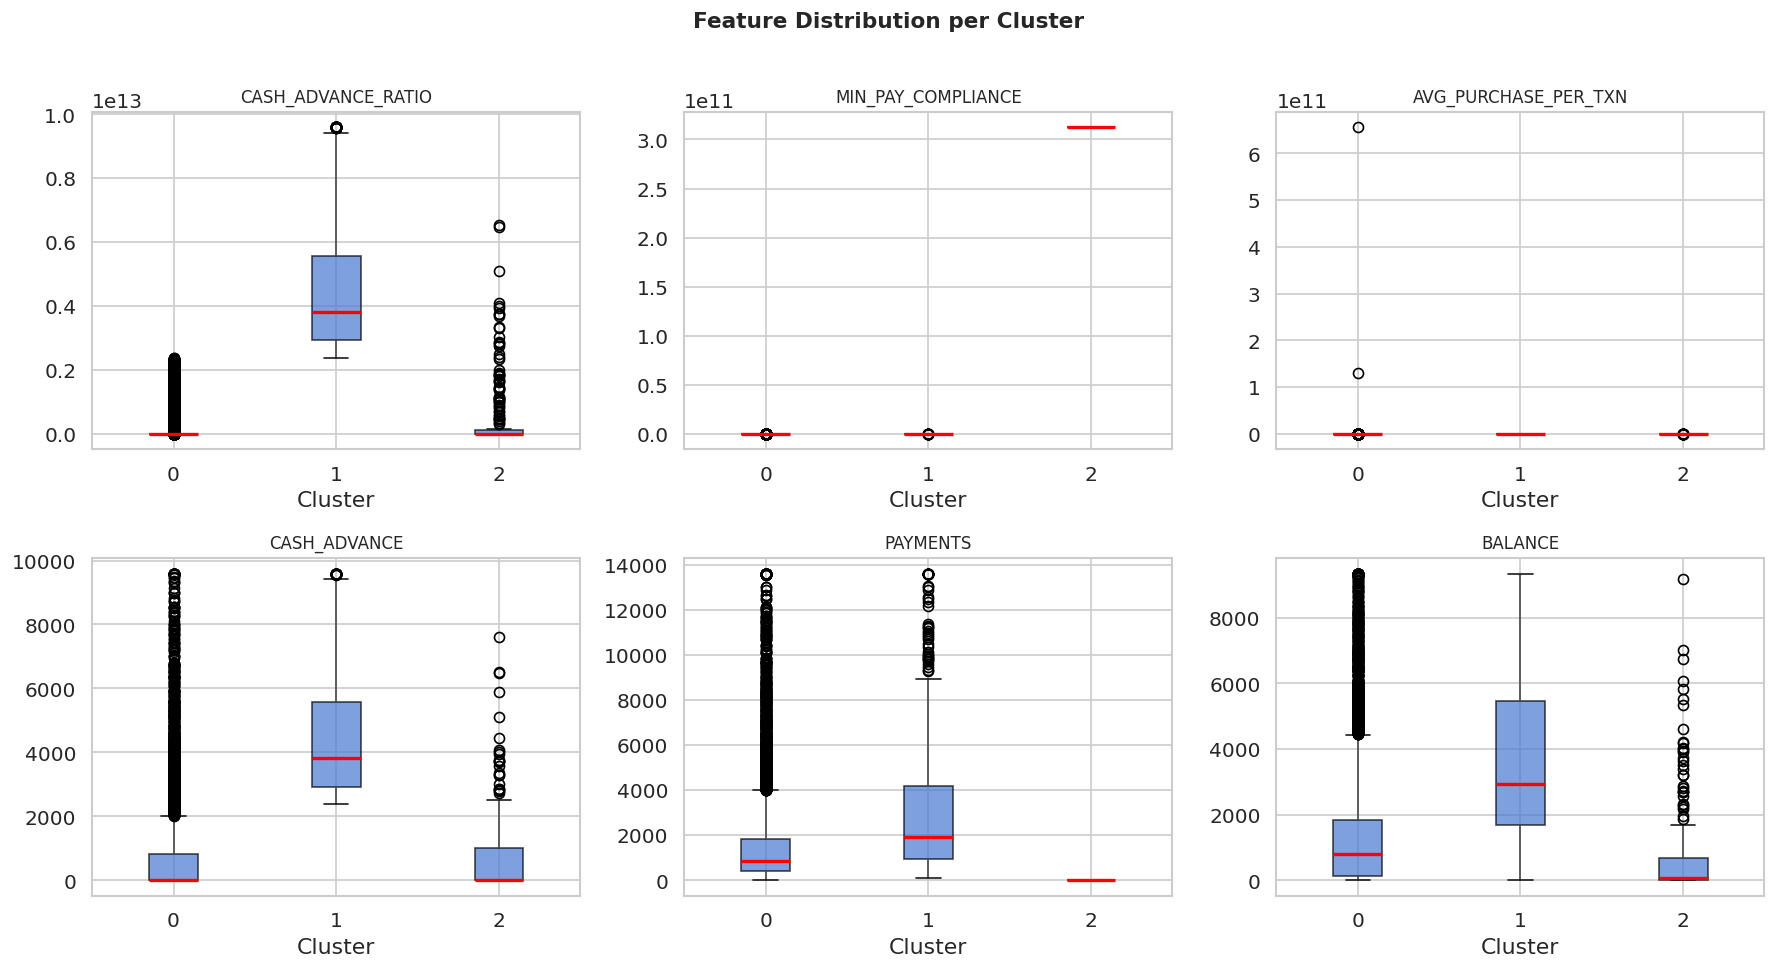

In [32]:
#  Box plots of key features per cluster
key_feats = radar_feats[:6]  # show top 6

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(key_feats):
    df_feat.boxplot(
        column=feat, by=LABEL_COL,
        ax=axes[i], patch_artist=True,
        boxprops=dict(alpha=0.7),
        medianprops=dict(color='red', lw=2)
    )
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('')

plt.suptitle('Feature Distribution per Cluster', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

In [34]:
#  Cluster persona narratives
print('='*65)
print(' CLUSTER PERSONAS — Interpretive Summary')
print('='*65)

for k in range(OPTIMAL_K):
    n   = sizes[k]
    pct = pcts[k]
    print(f'\n📌 Cluster {k}  ({n:,} customers — {pct}%)')
    print('-'*55)

    row = cluster_profile.iloc[k]

    # Dynamic description based on column availability
    lines = []
    if 'BALANCE' in row.index:
        lines.append(f'  Avg Balance:         {row["BALANCE"]:>12,.2f}')
    if 'PURCHASES' in row.index:
        lines.append(f'  Avg Purchases:       {row["PURCHASES"]:>12,.2f}')
    if 'PAYMENTS' in row.index:
        lines.append(f'  Avg Payments:        {row["PAYMENTS"]:>12,.2f}')
    if 'CREDIT_LIMIT' in row.index:
        lines.append(f'  Avg Credit Limit:    {row["CREDIT_LIMIT"]:>12,.2f}')
    if 'CASH_ADVANCE' in row.index:
        lines.append(f'  Avg Cash Advance:    {row["CASH_ADVANCE"]:>12,.2f}')
    if 'BALANCE_TO_LIMIT_RATIO' in row.index:
        lines.append(f'  Balance/Limit Ratio: {row["BALANCE_TO_LIMIT_RATIO"]:>12.3f}')
    if 'PAYMENT_TO_BALANCE_RATIO' in row.index:
        lines.append(f'  Payment/Balance:     {row["PAYMENT_TO_BALANCE_RATIO"]:>12.3f}')

    for line in lines:
        print(line)

 CLUSTER PERSONAS — Interpretive Summary

📌 Cluster 0  (8,133 customers — 90.9%)
-------------------------------------------------------
  Avg Balance:             1,414.77
  Avg Purchases:           1,018.07
  Avg Payments:            1,586.17
  Avg Credit Limit:        4,337.77
  Avg Cash Advance:          683.15
  Balance/Limit Ratio:        0.378
  Payment/Balance:          119.298

📌 Cluster 1  (577 customers — 6.4%)
-------------------------------------------------------
  Avg Balance:             3,661.18
  Avg Purchases:               0.00
  Avg Payments:            3,227.08
  Avg Credit Limit:        6,631.89
  Avg Cash Advance:        4,588.90
  Balance/Limit Ratio:        0.562
  Payment/Balance:            5.582

📌 Cluster 2  (240 customers — 2.7%)
-------------------------------------------------------
  Avg Balance:               722.96
  Avg Purchases:             413.66
  Avg Payments:                0.00
  Avg Credit Limit:        3,911.88
  Avg Cash Advance:          

## Conclusion & Business Insights: Customer Segmentation

Based on the evaluated unsupervised learning model, the customers can be grouped into 3 main segments/personas. Below is the interpretation of their characteristics along with recommended business strategies for each cluster:

### 📌 Cluster 0: "The Active Transactors" (90.9%)
*The majority of customers fall into this segment, demonstrating a stable and healthy financial profile.*

*   **Key Characteristics:**
    *   **Active Spenders:** Average transaction value (*Avg Purchases*) reaches 1,018.07.
    *   **High Payment Compliance:** Average bill payments (*Avg Payments*) are 1,586.17, with a highly healthy payment-to-balance ratio (119.29).
    *   **Minimal Cash Advances:** Rarely utilize the credit card's cash advance feature.
*   **Business Strategy:** This group requires no risk intervention. Focus on retention and loyalty programs—such as cashback, points reward systems, or tier upgrades (VIP)—to maintain their excellent transaction habits.

---

### 📌 Cluster 1: "The Cash Advance Users" (6.4%)
*A customer segment with the highest credit limit, but exhibiting a very specific card usage pattern focused entirely on cash liquidity.*

*   **Key Characteristics:**
    *   **Zero Purchases:** Average retail transactions (*Purchases*) are at 0.00. The card is not used for payments at merchants.
    *   **Massive Cash Advances:** They treat the credit card like an ATM, with a heavily dominant average cash advance (*Avg Cash Advance*) of 4,588.90.
    *   **Maximum Limit:** They possess the highest average credit limit (6,631.89) among all groups.
*   **Business Strategy:** Optimize revenue through cash advance fees. However, implement strict monitoring, as the habit of withdrawing large amounts of cash from a credit card can be an early indicator of a customer in need of emergency liquid funds.

---

### 📌 Cluster 2: "The High-Risk / Defaulters" (2.7%)
*A minority segment that serves as a red flag for the bank's receivables health and requires immediate intervention.*

*   **Key Characteristics:**
    *   **Non-Paying:** Average payments (*Avg Payments*) are exactly 0.00. There is no incoming cash flow to settle outstanding bills.
    *   **Debt Accumulation:** They are still recorded making transactions (average purchases of 413.66 and cash advances of 719.20), meaning their balance continues to grow without any repayment.
*   **Business Strategy:** Immediately implement a temporary freeze on their credit facilities or systematically lower their limits to prevent further loss exposure. Hand over this segment's data to the Collections department as a top priority before the accounts turn into bad debt.